# Exploratory Analysis: Olist Sales & Operations

This notebook explores the validated data in PostgreSQL. It reads the analytical views built by the pipeline
(`sql/analytical_views.sql`), so every number here matches the SQL analysis and the Tableau dashboards.

**Prerequisite:** run the pipeline once (`python -m src.pipeline`) so the database and views exist.
Charts are also saved to `docs/images/` for the README.

**Definitions:** revenue = item price + freight for orders that were not canceled or unavailable.
Late = delivered after the estimated date. Trend charts use January 2017 – August 2018.

In [1]:
import logging
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from src.database import query

logging.getLogger().setLevel(logging.WARNING)
pd.set_option("display.float_format", "{:,.2f}".format)

NAVY, BLUE, ORANGE, GREY = "#1F2A44", "#2E6FD8", "#E8833A", "#9AA3AF"
IMAGE_DIR = PROJECT_ROOT / "docs" / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.titlelocation": "left", "font.size": 10,
})


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(IMAGE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def millions(value: float, _position: int) -> str:
    return f"R${value / 1e6:.1f}M"

## 1. Data overview

In [2]:
query("""
    SELECT 'customers' AS table_name, COUNT(*) AS row_count FROM customers
    UNION ALL SELECT 'orders', COUNT(*) FROM orders
    UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
    UNION ALL SELECT 'payments', COUNT(*) FROM payments
    UNION ALL SELECT 'products', COUNT(*) FROM products
""")

,table_name,row_count
0,products,32951
1,orders,99441
2,customers,99441
3,payments,103886
4,order_items,112650


In [3]:
query("""
    SELECT MIN(order_purchase_date) AS first_order, MAX(order_purchase_date) AS last_order,
           COUNT(*) AS orders, COUNT(DISTINCT customer_unique_id) AS customers,
           ROUND(SUM(revenue), 2) AS revenue
    FROM operations_dashboard
""")

,first_order,last_order,orders,customers,revenue
0,2016-09-04,2018-10-17,99441,96096,"15,735,527.03"


## 2. Is the business growing?
Monthly revenue and the number of orders that generated revenue.

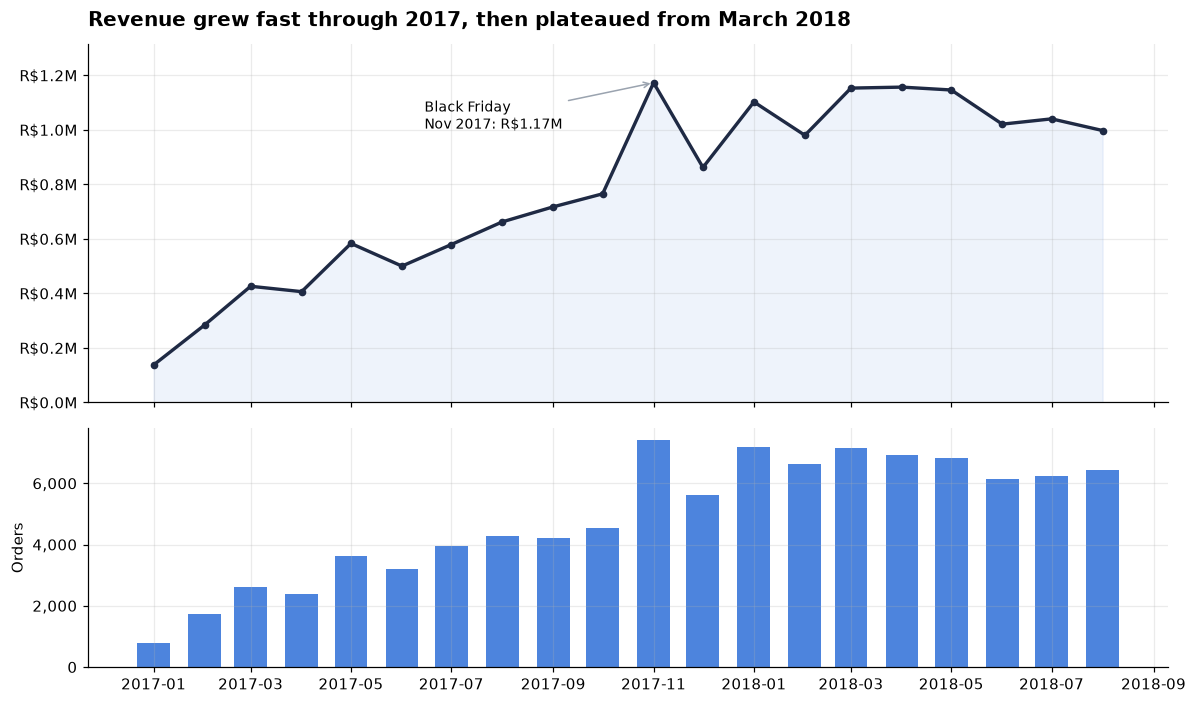

In [4]:
monthly = query("""
    SELECT order_month,
           SUM(revenue)                                  AS revenue,
           COUNT(*) FILTER (WHERE revenue IS NOT NULL)   AS revenue_orders
    FROM operations_dashboard
    WHERE in_trend_window
    GROUP BY order_month
    ORDER BY order_month
""")
monthly["order_month"] = pd.to_datetime(monthly["order_month"])
monthly["revenue"] = monthly["revenue"].astype(float)

fig, (ax_rev, ax_ord) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax_rev.plot(monthly["order_month"], monthly["revenue"], color=NAVY, linewidth=2.2, marker="o", markersize=4)
ax_rev.fill_between(monthly["order_month"], monthly["revenue"], color=BLUE, alpha=0.08)
ax_rev.yaxis.set_major_formatter(mtick.FuncFormatter(millions))
ax_rev.set_title("Revenue grew fast through 2017, then plateaued from March 2018", pad=12)
ax_rev.set_ylim(0, monthly["revenue"].max() * 1.12)
peak = monthly.loc[monthly["revenue"].idxmax()]
ax_rev.annotate(f"Black Friday\n{peak['order_month']:%b %Y}: R${peak['revenue'] / 1e6:.2f}M",
                xy=(peak["order_month"], peak["revenue"]), xytext=(-150, -30), textcoords="offset points",
                arrowprops={"arrowstyle": "->", "color": GREY}, fontsize=9)
ax_ord.bar(monthly["order_month"], monthly["revenue_orders"], width=20, color=BLUE, alpha=0.85)
ax_ord.set_ylabel("Orders")
ax_ord.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
fig.tight_layout()
save(fig, "monthly_revenue_orders")
plt.show()

Same months compared year over year (January–August), so seasonality doesn't distort growth:

In [5]:
def period(year: int) -> pd.Series:
    rows = monthly[(monthly["order_month"].dt.year == year) & (monthly["order_month"].dt.month <= 8)]
    revenue, orders = rows["revenue"].sum(), rows["revenue_orders"].sum()
    return pd.Series({"revenue": revenue, "revenue_orders": orders, "avg_order_value": revenue / orders})

yoy = pd.DataFrame({"Jan-Aug 2017": period(2017), "Jan-Aug 2018": period(2018)})
yoy["change_pct"] = (yoy["Jan-Aug 2018"] / yoy["Jan-Aug 2017"] - 1) * 100
yoy

,Jan-Aug 2017,Jan-Aug 2018,change_pct
revenue,"3,574,992.04","8,593,137.50",140.37
revenue_orders,"22,562.00","53,530.00",137.26
avg_order_value,158.45,160.53,1.31


**Finding:** growth came almost entirely from order volume. Average order value barely moved.

## 3. Where does revenue come from?

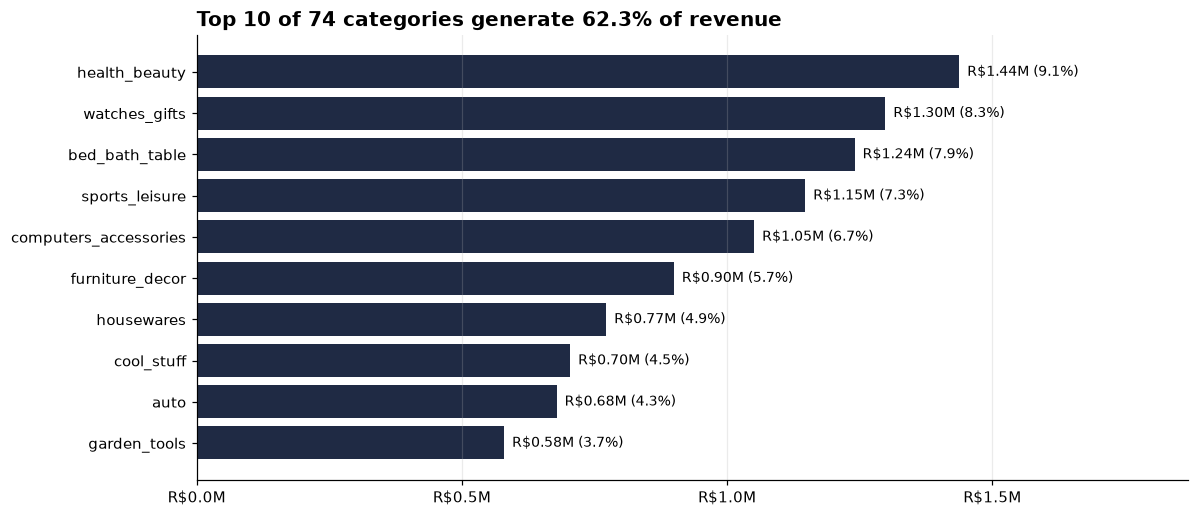

In [6]:
categories = query("""
    SELECT product_category, SUM(revenue) AS revenue
    FROM sales_dashboard
    WHERE revenue IS NOT NULL
    GROUP BY product_category
    ORDER BY revenue DESC
""")
categories["revenue"] = categories["revenue"].astype(float)
categories["share_pct"] = 100 * categories["revenue"] / categories["revenue"].sum()
top10 = categories.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.barh(top10["product_category"], top10["revenue"], color=NAVY)
for y, (revenue, share) in enumerate(zip(top10["revenue"], top10["share_pct"])):
    ax.text(revenue, y, f"  R${revenue / 1e6:.2f}M ({share:.1f}%)", va="center", fontsize=9)
ax.xaxis.set_major_locator(mtick.MultipleLocator(500_000))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(millions))
ax.set_xlim(0, top10["revenue"].max() * 1.3)
ax.grid(axis="y", visible=False)
ax.set_title(f"Top 10 of {len(categories)} categories generate {categories.head(10)['share_pct'].sum():.1f}% of revenue")
fig.tight_layout()
save(fig, "top_categories")
plt.show()

In [7]:
states = query("""
    SELECT customer_state, revenue, revenue_share_pct
    FROM regional_dashboard
    ORDER BY revenue DESC
""")
print(f"Top 3 states ({', '.join(states['customer_state'].head(3))}): "
      f"{states['revenue_share_pct'].head(3).astype(float).sum():.2f}% of revenue")
states.head(10)

Top 3 states (SP, RJ, MG): 62.52% of revenue


,customer_state,revenue,revenue_share_pct
0,SP,"5,878,132.06",37.36
1,RJ,"2,115,667.56",13.45
2,MG,"1,843,074.43",11.71
3,RS,"877,290.59",5.58
4,PR,"794,196.61",5.05
5,SC,"608,023.70",3.86
6,BA,"606,908.66",3.86
7,DF,"351,327.21",2.23
8,GO,"340,544.37",2.16
9,ES,"323,081.03",2.05


## 4. How reliable is delivery?

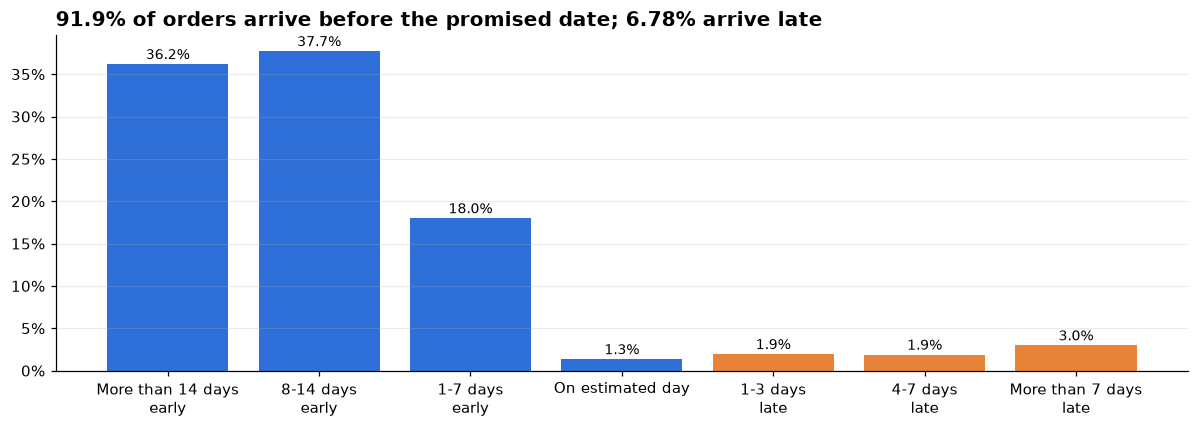

In [8]:
buckets = query("""
    SELECT timeliness_bucket, COUNT(*) AS orders
    FROM operations_dashboard
    WHERE is_measurable_delivery
    GROUP BY timeliness_bucket
    ORDER BY timeliness_bucket
""")
buckets["pct"] = 100 * buckets["orders"] / buckets["orders"].sum()
labels = buckets["timeliness_bucket"].str.replace(r"^\d\. ", "", regex=True)
colors = [ORANGE if "late" in label else BLUE for label in labels]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels.str.replace(" days ", " days\n", regex=False), buckets["pct"], color=colors)
for x, pct in enumerate(buckets["pct"]):
    ax.text(x, pct + 0.6, f"{pct:.1f}%", ha="center", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
early = buckets.loc[labels.str.contains("early"), "pct"].sum()
ax.set_title(f"{early:.1f}% of orders arrive before the promised date; "
             f"{buckets.loc[labels.str.contains('late'), 'pct'].sum():.2f}% arrive late")
fig.tight_layout()
save(fig, "delivery_vs_estimate")
plt.show()

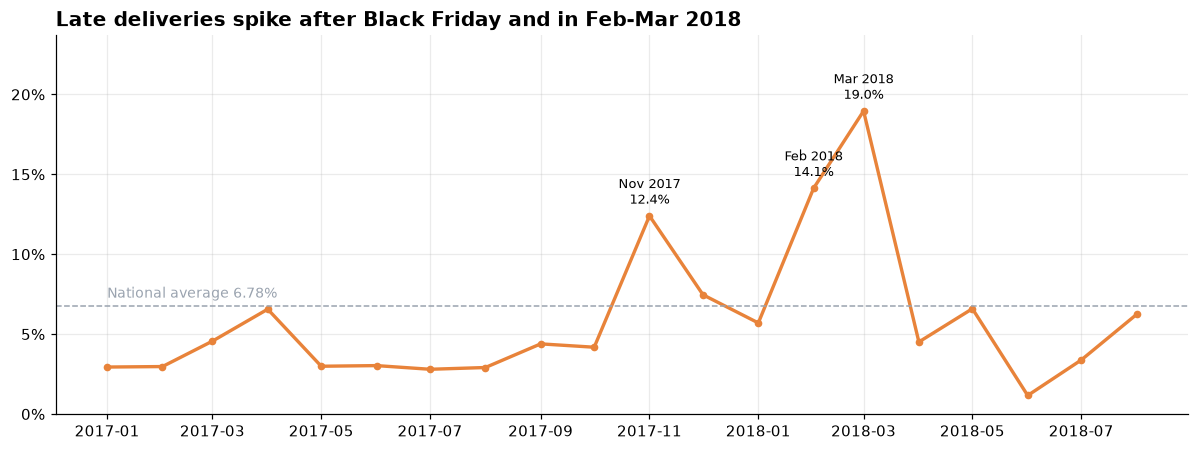

In [9]:
late_monthly = query("""
    SELECT order_month,
           COUNT(*)                                          AS delivered_orders,
           ROUND(100.0 * COUNT(*) FILTER (WHERE is_late) / COUNT(*), 2) AS late_pct
    FROM operations_dashboard
    WHERE is_measurable_delivery AND in_trend_window
    GROUP BY order_month
    ORDER BY order_month
""")
late_monthly["order_month"] = pd.to_datetime(late_monthly["order_month"])
late_monthly["late_pct"] = late_monthly["late_pct"].astype(float)
national = query("""
    SELECT ROUND(100.0 * COUNT(*) FILTER (WHERE is_late) / COUNT(*), 2) AS late_pct
    FROM operations_dashboard WHERE is_measurable_delivery
""")["late_pct"].astype(float).iloc[0]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(late_monthly["order_month"], late_monthly["late_pct"], color=ORANGE, linewidth=2.2, marker="o", markersize=4)
ax.axhline(national, color=GREY, linestyle="--", linewidth=1)
ax.text(late_monthly["order_month"].iloc[0], national + 0.5, f"National average {national:.2f}%", color=GREY, fontsize=9)
for _, row in late_monthly.nlargest(3, "late_pct").iterrows():
    ax.annotate(f"{row['order_month']:%b %Y}\n{row['late_pct']:.1f}%", (row["order_month"], row["late_pct"]),
                xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, late_monthly["late_pct"].max() * 1.25)
ax.set_title("Late deliveries spike after Black Friday and in Feb-Mar 2018")
fig.tight_layout()
save(fig, "late_rate_by_month")
plt.show()

### Which fulfilment stage causes the delay?
Average days spent in each stage, for late and on-time deliveries.

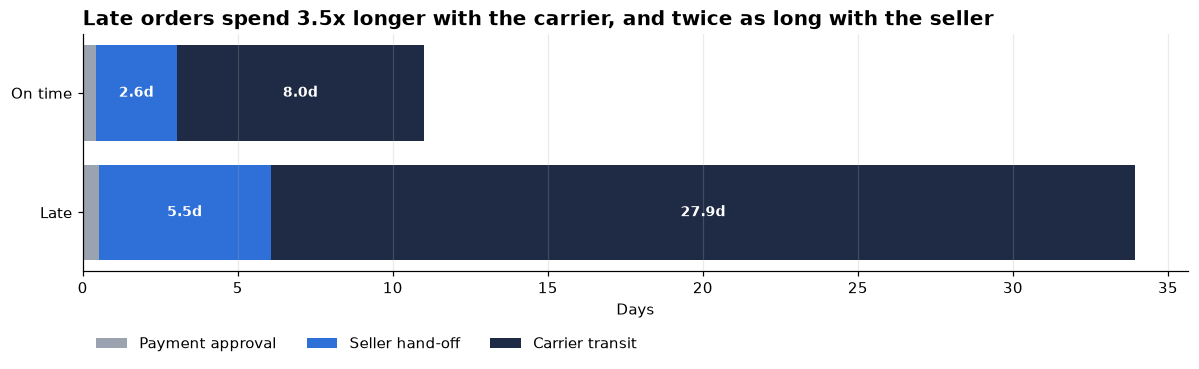

,approval_days,seller_handoff_days,carrier_transit_days
delivery_outcome,,,
Late,0.51,5.55,27.89
On time,0.42,2.60,7.98


In [10]:
stages = query("""
    SELECT delivery_outcome,
           AVG(approval_hours) / 24.0   AS approval_days,
           AVG(seller_handoff_days)     AS seller_handoff_days,
           AVG(carrier_transit_days)    AS carrier_transit_days
    FROM operations_dashboard
    WHERE is_measurable_delivery
    GROUP BY delivery_outcome
""").set_index("delivery_outcome").astype(float)

stage_labels = ["Payment approval", "Seller hand-off", "Carrier transit"]
fig, ax = plt.subplots(figsize=(11, 3.6))
left = pd.Series(0.0, index=stages.index)
for column, label, color in zip(stages.columns, stage_labels, [GREY, BLUE, NAVY]):
    ax.barh(stages.index, stages[column], left=left, color=color, label=label)
    for outcome in stages.index:
        if stages.loc[outcome, column] > 1.5:
            ax.text(left[outcome] + stages.loc[outcome, column] / 2, outcome, f"{stages.loc[outcome, column]:.1f}d",
                    ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    left += stages[column]
ax.set_xlabel("Days")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), frameon=False, ncol=3)
ax.set_title("Late orders spend 3.5x longer with the carrier, and twice as long with the seller")
fig.tight_layout()
save(fig, "fulfilment_stages")
plt.show()
stages

## 5. Which regions need attention?

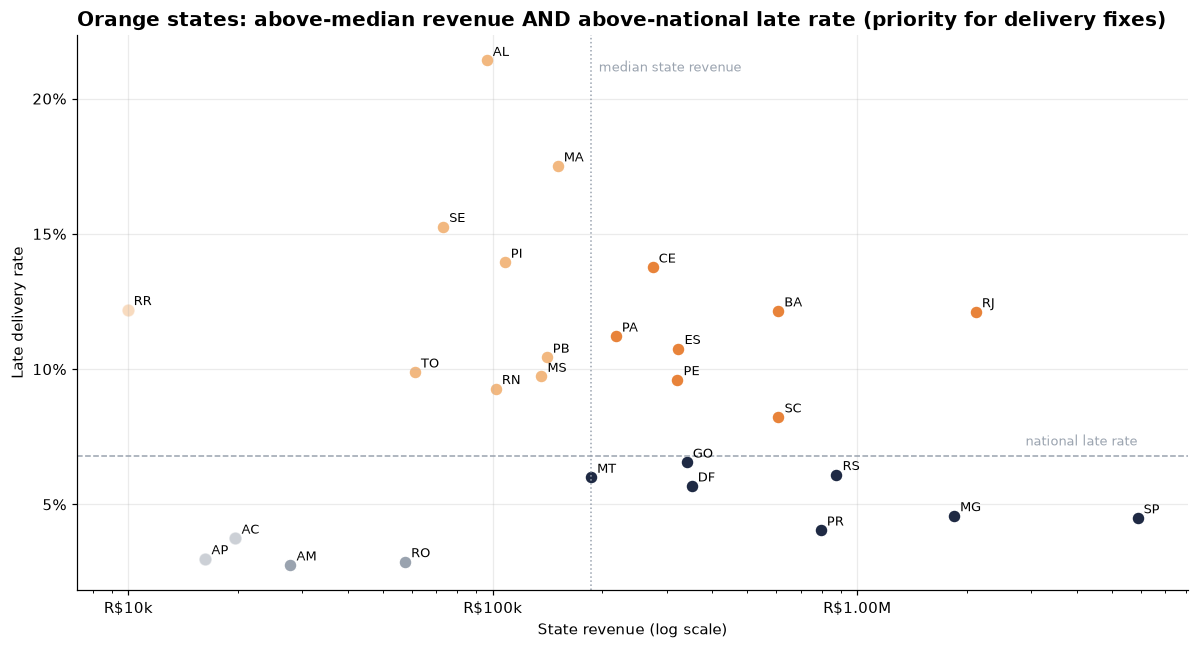

In [11]:
regions = query("""
    SELECT customer_state, revenue, late_pct, national_late_pct, revenue_tier, delivery_tier, segment, small_sample
    FROM regional_dashboard
""")
regions[["revenue", "late_pct", "national_late_pct"]] = regions[["revenue", "late_pct", "national_late_pct"]].astype(float)
median_revenue = regions["revenue"].median()

segment_colors = {
    ("Higher revenue", True): ORANGE, ("Higher revenue", False): NAVY,
    ("Lower revenue", True): "#F2B880", ("Lower revenue", False): GREY,
}
fig, ax = plt.subplots(figsize=(11, 6))
for _, row in regions.iterrows():
    above = row["late_pct"] > row["national_late_pct"]
    ax.scatter(row["revenue"], row["late_pct"], s=70, color=segment_colors[(row["revenue_tier"], above)],
               edgecolor="white", linewidth=0.8, alpha=0.5 if row["small_sample"] else 1)
    ax.annotate(row["customer_state"], (row["revenue"], row["late_pct"]), xytext=(4, 3), textcoords="offset points", fontsize=8.5)
ax.set_xscale("log")
ax.axhline(regions["national_late_pct"].iloc[0], color=GREY, linestyle="--", linewidth=1)
ax.axvline(median_revenue, color=GREY, linestyle=":", linewidth=1)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"R${v / 1e6:.2f}M" if v >= 1e6 else f"R${v / 1e3:.0f}k"))
ax.yaxis.set_major_locator(mtick.MultipleLocator(5))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.text(median_revenue * 1.05, regions["late_pct"].max(), "median state revenue", color=GREY, fontsize=8.5, va="top")
ax.set_xlabel("State revenue (log scale)")
ax.set_ylabel("Late delivery rate")
ax.text(regions["revenue"].max(), regions["national_late_pct"].iloc[0] + 0.4, "national late rate", ha="right", color=GREY, fontsize=8.5)
ax.set_title("Orange states: above-median revenue AND above-national late rate (priority for delivery fixes)")
fig.tight_layout()
save(fig, "state_segments")
plt.show()

In [12]:
query("""
    SELECT segment, COUNT(*) AS states, STRING_AGG(customer_state, ', ' ORDER BY revenue DESC) AS state_list,
           ROUND(SUM(revenue_share_pct), 2) AS revenue_share_pct,
           ROUND(100.0 * SUM(late_orders) / (SELECT SUM(late_orders) FROM regional_dashboard), 2) AS share_of_late_orders_pct
    FROM regional_dashboard
    GROUP BY segment
    ORDER BY revenue_share_pct DESC
""")

,segment,states,state_list,revenue_share_pct,share_of_late_orders_pct
0,Higher revenue / late rate at/below national,7,"SP, MG, RS, PR, DF, GO, MT",65.27,48.39
1,Higher revenue / late rate above national,7,"RJ, SC, BA, ES, PE, CE, PA",28.38,43.33
2,Lower revenue / late rate above national,9,"MA, PB, MS, PI, RN, AL, SE, TO, RR",5.56,8.04
3,Lower revenue / late rate at/below national,4,"RO, AM, AC, AP",0.77,0.24


## 6. Do customers come back?

In [13]:
query("""
    SELECT COUNT(*)                                             AS customers,
           COUNT(*) FILTER (WHERE orders > 1)                   AS repeat_customers,
           ROUND(100.0 * COUNT(*) FILTER (WHERE orders > 1) / COUNT(*), 2) AS repeat_pct
    FROM (
        SELECT customer_unique_id, COUNT(*) AS orders
        FROM operations_dashboard
        GROUP BY customer_unique_id
    ) AS per_customer
""")

,customers,repeat_customers,repeat_pct
0,96096,2997,3.12


## 7. Summary

| Theme | Finding |
|---|---|
| Growth | Jan–Aug 2018 revenue up ~140% year over year, driven by order count. Average order value flat |
| Momentum | Revenue flat since March 2018, and August is ~14% below the April peak |
| Concentration | Top 10 categories ≈ 62% of revenue. SP, RJ and MG ≈ 63% |
| Delivery | 92% of orders arrive early (estimates are conservative), 6.8% arrive late |
| Delays | Spikes after Black Friday 2017 and in Feb–Mar 2018. Carrier transit is the main cause |
| Regions | RJ, SC, BA, ES, PE, CE and PA: 28% of revenue but 43% of late orders |
| Retention | Only ~3% of customers ordered more than once |

Full write-up with recommendations: [`docs/business_insights.md`](../docs/business_insights.md).